In [76]:
import os
import torch
import pandas as pd
import numpy as np
import pickle
import re
from tqdm import tqdm
from transformers import T5Tokenizer, T5EncoderModel, BertModel, BertTokenizer, AutoTokenizer, EsmModel

# ================= 配置区域 =================
FASTA_04 = 'first_0.4.fasta'  
SEEDS = [42, 2023, 1234, 567, 100]
DATA_TYPES = ['train', 'test']
INPUT_DIR_TEMPLATE = "split_seed_{}" 

# 模型路径
PROTT5_PATH = "/home/gaozhw/encode_model/prot_t5_xl_uniref50"
PROTBERT_PATH = "/home/gaozhw/encode_model/prot_bert"
ESM2_PATH = "/home/gaozhw/encode_model/esm-2"

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

def parse_fasta(file_path):
    seq_dict = {}
    with open(file_path, 'r') as f:
        seq_id, sequence = None, []
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if seq_id: seq_dict[seq_id] = "".join(sequence)
                seq_id = line.split()[0].replace('>', '')
                sequence = []
            else: sequence.append(line)
        if seq_id: seq_dict[seq_id] = "".join(sequence)
    return seq_dict

# --- 编码函数：CKSAAP (k=5) ---
def get_cksaap(seq, k=5):
    AA = 'ACDEFGHIKLMNPQRSTVWY'
    pairs = [a + b for a in AA for b in AA]
    res = []
    for gap in range(k + 1):
        count = {}
        for p in pairs: count[p] = 0
        for i in range(len(seq) - gap - 1):
            p = seq[i] + seq[i + gap + 1]
            if p in count: count[p] += 1
        total_pairs = len(seq) - gap - 1
        for p in pairs:
            res.append(count[p] / total_pairs if total_pairs > 0 else 0)
    return np.array(res, dtype=np.float32)

# --- 深度学习特征提取逻辑 ---
@torch.no_grad()
def extract_plm_features(seq_dict, model_type):
    print(f"\n>>> 正在提取 {model_type} 特征...")
    ids = list(seq_dict.keys())
    raw_seqs = list(seq_dict.values())
    processed_seqs = [" ".join(list(re.sub(r"[UZOB]", "X", s))) for s in raw_seqs]
    
    if model_type == 'ProtT5':
        tokenizer = T5Tokenizer.from_pretrained(PROTT5_PATH, do_lower_case=False)
        model = T5EncoderModel.from_pretrained(PROTT5_PATH).to(DEVICE)
    elif model_type == 'ProtBert':
        tokenizer = BertTokenizer.from_pretrained(PROTBERT_PATH, do_lower_case=False)
        model = BertModel.from_pretrained(PROTBERT_PATH).to(DEVICE)
    elif model_type == 'ESM2':
        tokenizer = AutoTokenizer.from_pretrained(ESM2_PATH)
        model = EsmModel.from_pretrained(ESM2_PATH).to(DEVICE)
        processed_seqs = raw_seqs 

    model.eval()
    emb_map = {}
    for i, sid in enumerate(tqdm(ids)):
        inputs = tokenizer(processed_seqs[i], return_tensors="pt", padding=True).to(DEVICE)
        outputs = model(**inputs)
        # 取 Mean Pooling
        emb = outputs.last_hidden_state[0].mean(dim=0).cpu().numpy()
        emb_map[sid] = emb
    
    del model, tokenizer
    torch.cuda.empty_cache()
    return emb_map

def main():
    # 1. 定义原始参考文件路径以获取标签
    POS_REF_FILE = '515.fasta'
    NEG_REF_FILE = '872.fasta'

    # 2. 读取 0.4 去冗余后的全部序列
    master_seq_dict = parse_fasta(FASTA_04)
    
    # 3. 建立 ID 到 Label 的映射
    # 获取原始正负集的 ID 列表
    pos_ids = set(parse_fasta(POS_REF_FILE).keys())
    neg_ids = set(parse_fasta(NEG_REF_FILE).keys())
    
    # 4. 计算所有特征的 Master Dict (保持不变)
    print(">>> 正在计算 CKSAAP (k=5)...")
    cksaap_master = {sid: get_cksaap(seq) for sid, seq in master_seq_dict.items()}
    
    t5_master = extract_plm_features(master_seq_dict, 'ProtT5')
    bert_master = extract_plm_features(master_seq_dict, 'ProtBert')
    esm_master = extract_plm_features(master_seq_dict, 'ESM2')

    # 5. 分发数据并加入 Label
    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        print(f"\n>>> 正在分发种子 {seed} 的数据 (包含标签映射)...")
        
        for dtype in DATA_TYPES:
            fasta_path = os.path.join(folder, f"{dtype}.fasta")
            if not os.path.exists(fasta_path): continue
            
            subset_ids = list(parse_fasta(fasta_path).keys())
            combined_data = []
            
            for sid in subset_ids:
                # 判定标签：如果在 pos_ids 中则为 1，否则为 0
                label = 1 if sid in pos_ids else 0
                
                # 融合所有特征和标签到一个字典
                record = {
                    'id': sid,
                    'label': label, 
                    'cksaap': cksaap_master[sid],
                    'prot_t5': t5_master[sid],
                    'prot_bert': bert_master[sid],
                    'esm2': esm_master[sid]
                }
                combined_data.append(record)
            
            out_file = os.path.join(folder, f"{dtype}_features.pkl")
            with open(out_file, 'wb') as f:
                pickle.dump(combined_data, f)
            
            # 简单统计一下分发后的正负比例
            pos_count = sum([1 for x in combined_data if x['label'] == 1])
            neg_count = len(combined_data) - pos_count
            print(f"  - 已保存 {dtype}_features.pkl | 总数: {len(combined_data)} (正:{pos_count} / 负:{neg_count})")

if __name__ == "__main__":
    main()

>>> 正在计算 CKSAAP (k=5)...

>>> 正在提取 ProtT5 特征...


100%|██████████| 343/343 [01:29<00:00,  3.84it/s]



>>> 正在提取 ProtBert 特征...


100%|██████████| 343/343 [00:25<00:00, 13.35it/s]
Some weights of EsmModel were not initialized from the model checkpoint at /home/gaozhw/encode_model/esm-2 and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



>>> 正在提取 ESM2 特征...


100%|██████████| 343/343 [00:05<00:00, 60.80it/s]



>>> 正在分发种子 42 的数据 (包含标签映射)...
  - 已保存 train_features.pkl | 总数: 274 (正:80 / 负:194)
  - 已保存 test_features.pkl | 总数: 69 (正:20 / 负:49)

>>> 正在分发种子 2023 的数据 (包含标签映射)...
  - 已保存 train_features.pkl | 总数: 276 (正:82 / 负:194)
  - 已保存 test_features.pkl | 总数: 67 (正:18 / 负:49)

>>> 正在分发种子 1234 的数据 (包含标签映射)...
  - 已保存 train_features.pkl | 总数: 275 (正:80 / 负:195)
  - 已保存 test_features.pkl | 总数: 68 (正:20 / 负:48)

>>> 正在分发种子 567 的数据 (包含标签映射)...
  - 已保存 train_features.pkl | 总数: 275 (正:80 / 负:195)
  - 已保存 test_features.pkl | 总数: 68 (正:20 / 负:48)

>>> 正在分发种子 100 的数据 (包含标签映射)...
  - 已保存 train_features.pkl | 总数: 275 (正:81 / 负:194)
  - 已保存 test_features.pkl | 总数: 68 (正:19 / 负:49)


In [9]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, 
                             precision_score, recall_score, roc_auc_score, 
                             average_precision_score, confusion_matrix)

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
ENCODING_KEYS = ["prot_t5", "prot_bert", "esm2", "cksaap"]
INPUT_DIR_TEMPLATE = "split2_seed_{}" 

# MLP 超参数调优
BATCH_SIZE = 32
EPOCHS = 70
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

class SelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(SelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def get_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_true, y_probs)
        auprc = average_precision_score(y_true, y_probs)
    except:
        auc, auprc = 0.5, 0.0
    return {
        'Acc': accuracy_score(y_true, y_pred),
        'Sn (Rec)': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Sp': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': auc,
        'AUPRC': auprc
    }

def run_comprehensive_cv(X, y, seed, enc_name):
    """执行 10-Fold CV 并返回所有折的详细指标"""
    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        X_tr_t = torch.FloatTensor(X_train).to(DEVICE)
        y_tr_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
        X_va_t = torch.FloatTensor(X_val).to(DEVICE)

        model = SelectionMLP(X_train.shape[1]).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        criterion = nn.BCEWithLogitsLoss()
        
        best_fold_metrics = None
        best_fold_mcc = -1.0

        for epoch in range(EPOCHS):
            model.train()
            optimizer.zero_grad()
            loss = criterion(model(X_tr_t), y_tr_t)
            loss.backward()
            optimizer.step()
            
            if epoch % 2 == 0:
                model.eval()
                with torch.no_grad():
                    probs = torch.sigmoid(model(X_va_t)).cpu().numpy().flatten()
                    current_metrics = get_metrics(y_val, probs)
                    if current_metrics['MCC'] > best_fold_mcc:
                        best_fold_mcc = current_metrics['MCC']
                        best_fold_metrics = current_metrics
        
        best_fold_metrics.update({'Fold': fold + 1, 'Seed': seed, 'Encoding': enc_name})
        fold_results.append(best_fold_metrics)
    
    return fold_results

def main():
    all_detailed_data = []

    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_pkl = os.path.join(folder, "train_features.pkl")
        if not os.path.exists(train_pkl): continue
        
        with open(train_pkl, 'rb') as f: data = pickle.load(f)
        print(f"\n📊 Evaluating Seed {seed}...")

        for key in ENCODING_KEYS:
            X = np.stack([item[key] for item in data])
            y = np.array([item['label'] for item in data])
            
            # 运行 CV 并获取该特征下 10 份评估数据
            fold_results = run_comprehensive_cv(X, y, seed, key)
            all_detailed_data.extend(fold_results)
            
            avg_mcc = np.mean([f['MCC'] for f in fold_results])
            print(f"  > {key:10}: Mean MCC = {avg_mcc:.4f}")

    df_detailed = pd.DataFrame(all_detailed_data)
    df_detailed.to_csv("model_selection_detailed_full.csv", index=False)
    
    # 2. 生成汇总报表 (计算 Mean 和 Std)
    summary = df_detailed.groupby('Encoding').agg(['mean', 'std']).drop(columns=['Seed', 'Fold'])
    summary.to_csv("model_selection_summary_metrics.csv")
    
    print("\n✅ 评估完成！")
    print("详细数据已保存至: model_selection_detailed_full.csv")
    print("汇总报表已保存至: model_selection_summary_metrics.csv")
    print("\n汇总预览 (MCC & AUC):")
    print(summary[['MCC', 'AUC']])

if __name__ == "__main__":
    main()


📊 Evaluating Seed 42...
  > prot_t5   : Mean MCC = 0.8231
  > prot_bert : Mean MCC = 0.7764
  > esm2      : Mean MCC = 0.8014
  > cksaap    : Mean MCC = 0.6289

📊 Evaluating Seed 2023...
  > prot_t5   : Mean MCC = 0.8256
  > prot_bert : Mean MCC = 0.7908
  > esm2      : Mean MCC = 0.8018
  > cksaap    : Mean MCC = 0.7006

📊 Evaluating Seed 1234...
  > prot_t5   : Mean MCC = 0.8265
  > prot_bert : Mean MCC = 0.7553
  > esm2      : Mean MCC = 0.7728
  > cksaap    : Mean MCC = 0.6326

📊 Evaluating Seed 567...
  > prot_t5   : Mean MCC = 0.8301
  > prot_bert : Mean MCC = 0.7697
  > esm2      : Mean MCC = 0.8074
  > cksaap    : Mean MCC = 0.6707

📊 Evaluating Seed 100...
  > prot_t5   : Mean MCC = 0.8316
  > prot_bert : Mean MCC = 0.7688
  > esm2      : Mean MCC = 0.8396
  > cksaap    : Mean MCC = 0.7002

✅ 评估完成！
详细数据已保存至: model_selection_detailed_full.csv
汇总报表已保存至: model_selection_summary_metrics.csv

汇总预览 (MCC & AUC):
                MCC                 AUC          
               mean  

In [79]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, 
                             precision_score, recall_score, roc_auc_score, 
                             average_precision_score, confusion_matrix)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
try:
    from imblearn.ensemble import RUSBoostClassifier
except ImportError:
    RUSBoostClassifier = None

import warnings
warnings.filterwarnings("ignore")

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
FIXED_ENCODING = "prot_t5" 
INPUT_DIR_TEMPLATE = "split_seed_{}" 

BATCH_SIZE = 32
EPOCHS = 70
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

class SelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(SelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def get_comprehensive_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_true, y_probs)
        auprc = average_precision_score(y_true, y_probs)
    except:
        auc, auprc = 0.5, 0.0
    return {
        'Acc': accuracy_score(y_true, y_pred),
        'Sn (Rec)': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Sp': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': auc,
        'AUPRC': auprc
    }

def main():
    all_detailed_data = []

    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_pkl = os.path.join(folder, "train_features.pkl")
        if not os.path.exists(train_pkl): continue
        
        with open(train_pkl, 'rb') as f: data = pickle.load(f)
        X_raw = np.stack([item[FIXED_ENCODING] for item in data])
        y_raw = np.array([item['label'] for item in data])
        
        print(f"\n🚀 Seed {seed} | 启动多算法 Benchmark 对比...")
        kf = KFold(n_splits=10, shuffle=True, random_state=seed)
        
        for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw)):
            X_tr, X_va = X_raw[tr_idx], X_raw[va_idx]
            y_tr, y_va = y_raw[tr_idx], y_raw[va_idx]
            
            scaler = StandardScaler()
            X_tr, X_va = scaler.fit_transform(X_tr), scaler.transform(X_va)

            svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=seed)
            svm.fit(X_tr, y_tr)
            svm_probs = svm.predict_proba(X_va)[:, 1]

            lr = LogisticRegression(max_iter=1000, random_state=seed)
            lr.fit(X_tr, y_tr)
            lr_probs = lr.predict_proba(X_va)[:, 1]

            knn = KNeighborsClassifier(n_neighbors=5)
            knn.fit(X_tr, y_tr)
            knn_probs = knn.predict_proba(X_va)[:, 1]

            dt = DecisionTreeClassifier(random_state=seed)
            dt.fit(X_tr, y_tr)
            dt_probs = dt.predict_proba(X_va)[:, 1]

            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
            rf.fit(X_tr, y_tr)
            rf_probs = rf.predict_proba(X_va)[:, 1]

            gbdt = GradientBoostingClassifier(n_estimators=100, random_state=seed)
            gbdt.fit(X_tr, y_tr)
            gbdt_probs = gbdt.predict_proba(X_va)[:, 1]

            xgb = XGBClassifier(eval_metric='logloss', random_state=seed)
            xgb.fit(X_tr, y_tr)
            xgb_probs = xgb.predict_proba(X_va)[:, 1]

            if RUSBoostClassifier:
                rus = RUSBoostClassifier(n_estimators=100, random_state=seed)
            else:
                rus = AdaBoostClassifier(n_estimators=100, random_state=seed)
            rus.fit(X_tr, y_tr)
            rus_probs = rus.predict_proba(X_va)[:, 1]

            X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
            y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
            X_va_t = torch.FloatTensor(X_va).to(DEVICE)

            model = SelectionMLP(X_tr.shape[1]).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
            criterion = nn.BCEWithLogitsLoss()
            
            best_mlp_probs = None
            best_mcc = -1.0
            for epoch in range(EPOCHS):
                model.train()
                optimizer.zero_grad()
                loss = criterion(model(X_tr_t), y_tr_t)
                loss.backward()
                optimizer.step()
                if epoch % 5 == 0:
                    model.eval()
                    with torch.no_grad():
                        current_probs = torch.sigmoid(model(X_va_t)).cpu().numpy().flatten()
                        current_mcc = matthews_corrcoef(y_va, (current_probs > 0.5).astype(int))
                        if current_mcc > best_mcc:
                            best_mcc = current_mcc
                            best_mlp_probs = current_probs

            results_map = {
                'MLP': best_mlp_probs,
                'SVM': svm_probs,
                'LogisticRegression': lr_probs,
                'KNN': knn_probs,
                'DecisionTree': dt_probs,
                'RandomForest': rf_probs,
                'GradientBoosting': gbdt_probs,
                'XGBoost': xgb_probs,
                'RUSBoost': rus_probs
            }

            for name, probs in results_map.items():
                m = get_comprehensive_metrics(y_va, probs)
                m.update({'Algo': name, 'Seed': seed, 'Fold': fold + 1})
                all_detailed_data.append(m)
            
            print(f"  Fold {fold+1} 完成...")

    df_full = pd.DataFrame(all_detailed_data)
    df_full.to_csv("comprehensive_algo_benchmarking.csv", index=False)
    
    summary = df_full.groupby('Algo').agg(['mean', 'std']).drop(columns=['Seed', 'Fold'])
    summary.to_csv("comprehensive_algo_summary.csv")
    
    print("\n✅ 对比完成！各算法平均表现（按 AUC 排序）：")
    sorted_summary = summary.sort_values(('AUC', 'mean'), ascending=False)
    print(sorted_summary[[('MCC', 'mean'), ('AUC', 'mean'), ('Sn (Rec)', 'mean'), ('Sp', 'mean')]])

if __name__ == "__main__":
    main()


🚀 Seed 42 | 启动多算法 Benchmark 对比...
  Fold 1 完成...
  Fold 2 完成...
  Fold 3 完成...
  Fold 4 完成...
  Fold 5 完成...
  Fold 6 完成...
  Fold 7 完成...
  Fold 8 完成...
  Fold 9 完成...
  Fold 10 完成...

🚀 Seed 2023 | 启动多算法 Benchmark 对比...
  Fold 1 完成...
  Fold 2 完成...
  Fold 3 完成...
  Fold 4 完成...
  Fold 5 完成...
  Fold 6 完成...
  Fold 7 完成...
  Fold 8 完成...
  Fold 9 完成...
  Fold 10 完成...

🚀 Seed 1234 | 启动多算法 Benchmark 对比...
  Fold 1 完成...
  Fold 2 完成...
  Fold 3 完成...
  Fold 4 完成...
  Fold 5 完成...
  Fold 6 完成...
  Fold 7 完成...
  Fold 8 完成...
  Fold 9 完成...
  Fold 10 完成...

🚀 Seed 567 | 启动多算法 Benchmark 对比...
  Fold 1 完成...
  Fold 2 完成...
  Fold 3 完成...
  Fold 4 完成...
  Fold 5 完成...
  Fold 6 完成...
  Fold 7 完成...
  Fold 8 完成...
  Fold 9 完成...
  Fold 10 完成...

🚀 Seed 100 | 启动多算法 Benchmark 对比...
  Fold 1 完成...
  Fold 2 完成...
  Fold 3 完成...
  Fold 4 完成...
  Fold 5 完成...
  Fold 6 完成...
  Fold 7 完成...
  Fold 8 完成...
  Fold 9 完成...
  Fold 10 完成...

✅ 对比完成！各算法平均表现（按 AUC 排序）：
                         MCC       AU

In [80]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, 
                             precision_score, recall_score, roc_auc_score, 
                             average_precision_score, confusion_matrix)
import warnings

warnings.filterwarnings("ignore")

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
FIXED_ENCODING = "prot_t5" 
INPUT_DIR_TEMPLATE = "split_seed_{}" 

BATCH_SIZE = 64
EPOCHS = 60
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

class SelectionCNN(nn.Module):
    def __init__(self, input_dim):
        super(SelectionCNN, self).__init__()
        # 假设输入维度是 (Batch, 1, input_dim)
        self.conv_layer = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # 自动计算卷积后的维度
        self.feature_dim = (input_dim // 2) // 2 
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # x shape: (Batch, input_dim) -> (Batch, 1, input_dim)
        x = x.unsqueeze(1)
        x = self.conv_layer(x)
        return self.classifier(x)

def get_comprehensive_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_true, y_probs)
        auprc = average_precision_score(y_true, y_probs)
    except:
        auc, auprc = 0.5, 0.0
    return {
        'Acc': accuracy_score(y_true, y_pred),
        'Sn (Rec)': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Sp': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': auc,
        'AUPRC': auprc
    }

def main():
    all_detailed_data = []

    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_pkl = os.path.join(folder, "train_features.pkl")
        if not os.path.exists(train_pkl): continue
        
        with open(train_pkl, 'rb') as f: data = pickle.load(f)
        X_raw = np.stack([item[FIXED_ENCODING] for item in data])
        y_raw = np.array([item['label'] for item in data])
        
        print(f"\n🚀 Seed {seed} | 启动 CNN 性能评估...")
        kf = KFold(n_splits=10, shuffle=True, random_state=seed)
        
        for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw)):
            X_tr, X_va = X_raw[tr_idx], X_raw[va_idx]
            y_tr, y_va = y_raw[tr_idx], y_raw[va_idx]
            
            scaler = StandardScaler()
            X_tr, X_va = scaler.fit_transform(X_tr), scaler.transform(X_va)

            # 转换为 PyTorch 张量
            X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
            y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
            X_va_t = torch.FloatTensor(X_va).to(DEVICE)

            # 初始化模型
            model = SelectionCNN(X_tr.shape[1]).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
            criterion = nn.BCEWithLogitsLoss()
            
            best_cnn_probs = None
            best_mcc = -1.0

            # 训练循环
            for epoch in range(EPOCHS):
                model.train()
                optimizer.zero_grad()
                outputs = model(X_tr_t)
                loss = criterion(outputs, y_tr_t)
                loss.backward()
                optimizer.step()
                
                # 每5代进行验证
                if epoch % 5 == 0:
                    model.eval()
                    with torch.no_grad():
                        current_probs = torch.sigmoid(model(X_va_t)).cpu().numpy().flatten()
                        current_mcc = matthews_corrcoef(y_va, (current_probs > 0.5).astype(int))
                        if current_mcc > best_mcc:
                            best_mcc = current_mcc
                            best_cnn_probs = current_probs

            m = get_comprehensive_metrics(y_va, best_cnn_probs)
            m.update({'Algo': 'CNN', 'Seed': seed, 'Fold': fold + 1})
            all_detailed_data.append(m)
            
            print(f"   Fold {fold+1} 完成 | MCC: {best_mcc:.4f}")

    df_full = pd.DataFrame(all_detailed_data)
    df_full.to_csv("cnn_benchmarking_results.csv", index=False)
    
    summary = df_full.groupby('Algo').agg(['mean', 'std']).drop(columns=['Seed', 'Fold'])
    print("\n✅ CNN 评估完成！")
    print(summary[[('MCC', 'mean'), ('AUC', 'mean'), ('Sn (Rec)', 'mean'), ('Sp', 'mean')]])

if __name__ == "__main__":
    main()


🚀 Seed 42 | 启动 CNN 性能评估...
   Fold 1 完成 | MCC: 0.7817
   Fold 2 完成 | MCC: 0.7372
   Fold 3 完成 | MCC: 0.9234
   Fold 4 完成 | MCC: 0.7303
   Fold 5 完成 | MCC: 0.7347
   Fold 6 完成 | MCC: 1.0000
   Fold 7 完成 | MCC: 0.7753
   Fold 8 完成 | MCC: 0.9117
   Fold 9 完成 | MCC: 0.5294
   Fold 10 完成 | MCC: 0.5976

🚀 Seed 2023 | 启动 CNN 性能评估...
   Fold 1 完成 | MCC: 0.6774
   Fold 2 完成 | MCC: 0.8928
   Fold 3 完成 | MCC: 0.6623
   Fold 4 完成 | MCC: 0.8444
   Fold 5 完成 | MCC: 0.6500
   Fold 6 完成 | MCC: 0.8363
   Fold 7 完成 | MCC: 0.7714
   Fold 8 完成 | MCC: 0.8333
   Fold 9 完成 | MCC: 0.6064
   Fold 10 完成 | MCC: 0.9035

🚀 Seed 1234 | 启动 CNN 性能评估...
   Fold 1 完成 | MCC: 0.8095
   Fold 2 完成 | MCC: 1.0000
   Fold 3 完成 | MCC: 0.5477
   Fold 4 完成 | MCC: 0.6000
   Fold 5 完成 | MCC: 0.9129
   Fold 6 完成 | MCC: 0.7347
   Fold 7 完成 | MCC: 0.6929
   Fold 8 完成 | MCC: 0.5669
   Fold 9 完成 | MCC: 0.8460
   Fold 10 完成 | MCC: 0.6625

🚀 Seed 567 | 启动 CNN 性能评估...
   Fold 1 完成 | MCC: 0.9045
   Fold 2 完成 | MCC: 0.7430
   Fold 3 完成 | M

In [85]:
import pandas as pd

# 1. 读取 CNN 结果
cnn_results_path = "cnn_benchmarking_results.csv"
summary_path = "comprehensive_algo_summary.csv"

if not pd.io.common.file_exists(cnn_results_path):
    print(f"错误：找不到文件 {cnn_results_path}")
else:
    df_cnn = pd.read_csv(cnn_results_path)

    cols_to_exclude = ['Seed', 'Fold']
    metrics_df = df_cnn.drop(columns=[col for col in cols_to_exclude if col in df_cnn.columns])

    cnn_summary = metrics_df.groupby('Algo').agg(['mean', 'std'])

    print("📊 当前 CNN 统计结果：")
    print(cnn_summary)

    if pd.io.common.file_exists(summary_path):
        existing_summary = pd.read_csv(summary_path, header=[0, 1], index_col=0)

        updated_summary = pd.concat([existing_summary, cnn_summary])
        updated_summary = updated_summary[~updated_summary.index.duplicated(keep='last')]
        
        updated_summary.to_csv(summary_path)
        print(f"\n✅ 已成功将 CNN 结果追加至 {summary_path}")
    else:
        cnn_summary.to_csv(summary_path)
        print(f"\n⚠️ 未找到原汇总文件，已创建新的 {summary_path}")

    try:
        final_view = pd.read_csv(summary_path, header=[0, 1], index_col=0)
        sorted_view = final_view.sort_values(('AUC', 'mean'), ascending=False)
        print("\n🏆 所有算法最终排名 (按 AUC 排序):")
        print(sorted_view[[('MCC', 'mean'), ('AUC', 'mean'), ('Sn (Rec)', 'mean')]])
    except Exception as e:
        print(f"打印排名时出错: {e}")

📊 当前 CNN 统计结果：
           Acc           Sn (Rec)                  Sp              Prec                  F1                 MCC                 AUC               AUPRC          
          mean      std      mean       std      mean     std      mean       std      mean       std      mean       std      mean       std      mean       std
Algo                                                                                                                                                             
CNN   0.901085  0.05127  0.736288  0.160179  0.969699  0.0442  0.918567  0.116104  0.802654  0.114649  0.756568  0.126232  0.904049  0.072626  0.864679  0.092352

✅ 已成功将 CNN 结果追加至 comprehensive_algo_summary.csv

🏆 所有算法最终排名 (按 AUC 排序):
                         MCC       AUC  Sn (Rec)
                        mean      mean      mean
Algo                                            
SVM                 0.787570  0.924401  0.788239
XGBoost             0.702143  0.921491  0.701177
LogisticRegression 

In [5]:
import pandas as pd
import os

# ================= 配置区域 =================
INPUT_FILE = "comprehensive_algo_summary.csv"
OUTPUT_FILE = "comprehensive_algo_formatted_final.csv"

METRIC_ORDER = ['Sn (Rec)', 'Sp', 'MCC', 'AUC', 'AUPRC']

# 定义按照哪个指标排序（默认 MCC 降序，把最好的模型放第一行）
SORT_BY_METRIC = 'MCC'
# ===========================================

def format_summary_csv():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误：找不到文件 {INPUT_FILE}")
        return

    print(f"📖 正在读取 {INPUT_FILE}...")
    
    df = pd.read_csv(INPUT_FILE, header=[0, 1], index_col=0)

    final_df = pd.DataFrame(index=df.index)

    sort_values = None

    print("⚙️  正在格式化数据...")
    for metric in METRIC_ORDER:
        # 检查指标是否存在于数据中
        if metric not in df.columns.levels[0]:
            print(f"⚠️ 警告：指标 {metric} 不在数据中，跳过。")
            continue
        
        mean_col = df[metric]['mean']
        std_col = df[metric]['std']
        
        if metric == SORT_BY_METRIC:
            sort_values = mean_col
        final_df[metric] = (
            mean_col.map('{:.4f}'.format) + 
            " ± " + 
            std_col.map('{:.4f}'.format)
        )

    if sort_values is not None:
        sorted_indices = sort_values.argsort()[::-1]
        final_df = final_df.iloc[sorted_indices]
        print(f"📉 已根据 {SORT_BY_METRIC} (Mean) 降序排列。")

    # 保存
    final_df.to_csv(OUTPUT_FILE)
    
    print("\n" + "="*50)
    print("✅ 格式转换完成！")
    print(f"文件已保存为: {OUTPUT_FILE}")
    print("="*50)
    
    # 预览
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n表格预览 (Top 5):")
    print(final_df.head())

if __name__ == "__main__":
    format_summary_csv()

📖 正在读取 comprehensive_algo_summary.csv...
⚙️  正在格式化数据...
📉 已根据 MCC (Mean) 降序排列。

✅ 格式转换完成！
文件已保存为: comprehensive_algo_formatted_final.csv

表格预览 (Top 5):
                           Sn (Rec)               Sp              MCC              AUC            AUPRC
Algo                                                                                                   
MLP                 0.8493 ± 0.1216  0.9659 ± 0.0419  0.8321 ± 0.1062  0.9171 ± 0.0703  0.8888 ± 0.0979
SVM                 0.7882 ± 0.1320  0.9664 ± 0.0398  0.7876 ± 0.1187  0.9244 ± 0.0580  0.8999 ± 0.0744
CNN                 0.7363 ± 0.1602  0.9697 ± 0.0442  0.7566 ± 0.1262  0.9040 ± 0.0726  0.8647 ± 0.0924
LogisticRegression  0.8064 ± 0.1398  0.9342 ± 0.0556  0.7481 ± 0.1434  0.9173 ± 0.0676  0.8835 ± 0.0882
XGBoost             0.7012 ± 0.1451  0.9558 ± 0.0404  0.7021 ± 0.1279  0.9215 ± 0.0541  0.8744 ± 0.0814


In [94]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, 
                             precision_score, recall_score, roc_auc_score, 
                             average_precision_score, confusion_matrix)

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
INPUT_DIR_TEMPLATE = "split_seed_{}" 
FIXED_ENCODING = "prot_t5"

# 输出目录：保存模型和Scaler的地方
OUTPUT_MODEL_DIR = "saved_models_2026_eval"
if not os.path.exists(OUTPUT_MODEL_DIR):
    os.makedirs(OUTPUT_MODEL_DIR)

BATCH_SIZE = 32
EPOCHS = 70
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

# --- 锁定模型结构 ---
class FinalSelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(FinalSelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x): return self.net(x)

def get_full_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    try:
        auc = roc_auc_score(y_true, y_probs)
        auprc = average_precision_score(y_true, y_probs)
    except:
        auc, auprc = 0.5, 0.0

    return {
        'Acc': accuracy_score(y_true, y_pred),
        'Sn (Rec)': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Sp': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': auc,
        'AUPRC': auprc
    }

def main():
    final_results = []

    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_path = os.path.join(folder, "train_features.pkl")
        val_path = os.path.join(folder, "test_features.pkl")
        
        if not (os.path.exists(train_path) and os.path.exists(val_path)):
            continue
            
        print(f"🚀 Processing Seed {seed}...")
        
        # 1. 加载数据
        with open(train_path, 'rb') as f: tr_data = pickle.load(f)
        with open(val_path, 'rb') as f: va_data = pickle.load(f)

        X_tr = np.stack([i[FIXED_ENCODING] for i in tr_data])
        y_tr = np.array([i['label'] for i in tr_data])
        X_va = np.stack([i[FIXED_ENCODING] for i in va_data])
        y_va = np.array([i['label'] for i in va_data])

        # 2. 预处理 (标准化) & 保存Scaler
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)
        
        scaler_path = os.path.join(OUTPUT_MODEL_DIR, f"scaler_seed_{seed}.pkl")
        with open(scaler_path, 'wb') as f:
            pickle.dump(scaler, f)

        # 3. 准备 Tensor
        X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
        y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
        X_va_t = torch.FloatTensor(X_va).to(DEVICE)

        # 4. 初始化模型
        model = FinalSelectionMLP(X_tr.shape[1]).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        criterion = nn.BCEWithLogitsLoss()

        # 5. 训练
        best_mcc = -1.0
        best_metrics = None
        
        for epoch in range(EPOCHS):
            model.train()
            optimizer.zero_grad()
            loss = criterion(model(X_tr_t), y_tr_t)
            loss.backward()
            optimizer.step()
            
            # 评估
            if epoch % 2 == 0:  # 稍微减少评估频率以加速
                model.eval()
                with torch.no_grad():
                    probs = torch.sigmoid(model(X_va_t)).cpu().numpy().flatten()
                    m = get_full_metrics(y_va, probs)
                    if m['MCC'] > best_mcc:
                        best_mcc = m['MCC']
                        best_metrics = m
                        
                        # --- 关键修改：保存最佳模型权重 ---
                        model_save_path = os.path.join(OUTPUT_MODEL_DIR, f"model_seed_{seed}.pth")
                        torch.save(model.state_dict(), model_save_path)
        
        best_metrics['Seed'] = seed
        final_results.append(best_metrics)
        print(f"   - Best MCC for Seed {seed}: {best_mcc:.4f}")
        print(f"   - Model saved to: {model_save_path}")

    # 汇总并保存
    df = pd.DataFrame(final_results)
    df.to_csv("final_fixed_model_evaluation.csv", index=False)
    summary = df.drop(columns='Seed').agg(['mean', 'std'])
    summary.to_csv("final_fixed_model_summary.csv")
    
    print("\n✅ 固定模型评估完成！模型已保存至 saved_models_2026_eval 文件夹。")

if __name__ == "__main__":
    main()

🚀 Processing Seed 42...
   - Best MCC for Seed 42: 0.8357
   - Model saved to: saved_models_2026_eval/model_seed_42.pth
🚀 Processing Seed 2023...
   - Best MCC for Seed 2023: 0.8847
   - Model saved to: saved_models_2026_eval/model_seed_2023.pth
🚀 Processing Seed 1234...
   - Best MCC for Seed 1234: 0.8260
   - Model saved to: saved_models_2026_eval/model_seed_1234.pth
🚀 Processing Seed 567...
   - Best MCC for Seed 567: 0.8208
   - Model saved to: saved_models_2026_eval/model_seed_567.pth
🚀 Processing Seed 100...
   - Best MCC for Seed 100: 0.7407
   - Model saved to: saved_models_2026_eval/model_seed_100.pth

✅ 固定模型评估完成！模型已保存至 saved_models_2026_eval 文件夹。


In [2]:
import pandas as pd
import os

# ================= 配置区域 =================
INPUT_FILE = "final_fixed_model_summary.csv"
OUTPUT_FILE = "final_fixed_model_formatted.csv"
MODEL_NAME = "ProtT5-MLP (Independent Test)"
METRIC_ORDER = ['Sn (Rec)', 'Sp', 'MCC', 'AUC', 'AUPRC']
# ===========================================

def format_fixed_summary():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误：找不到文件 {INPUT_FILE}")
        return

    print(f"📖 正在读取 {INPUT_FILE}...")
    
    df = pd.read_csv(INPUT_FILE, index_col=0)
    formatted_data = {'Model': MODEL_NAME}
    print("⚙️  正在格式化数据...")
    
    # 遍历你指定的指标顺序
    for metric in METRIC_ORDER:
        if metric not in df.columns:
            print(f"⚠️ 警告：指标 {metric} 不在数据中，跳过。")
            continue
            
        # 直接通过 loc 获取均值和标准差
        mean_val = df.loc['mean', metric]
        std_val = df.loc['std', metric]

        formatted_data[metric] = f"{mean_val:.4f} ± {std_val:.4f}"

    final_df = pd.DataFrame([formatted_data])
    final_df.to_csv(OUTPUT_FILE, index=False)
    
    print("\n" + "="*50)
    print("✅ 格式转换完成！")
    print(f"文件已保存为: {OUTPUT_FILE}")
    print("="*50)

    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n表格预览:")
    print(final_df)

if __name__ == "__main__":
    format_fixed_summary()

📖 正在读取 final_fixed_model_summary.csv...
⚙️  正在格式化数据...

✅ 格式转换完成！
文件已保存为: final_fixed_model_formatted.csv

表格预览:
                           Model         Sn (Rec)               Sp              MCC              AUC            AUPRC
0  ProtT5-MLP (Independent Test)  0.8757 ± 0.0600  0.9465 ± 0.0233  0.8216 ± 0.0518  0.9222 ± 0.0330  0.8936 ± 0.0428


In [12]:
# 学习曲线

import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, 
                             precision_score, recall_score, roc_auc_score, 
                             average_precision_score, confusion_matrix)
from sklearn.model_selection import train_test_split

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
INPUT_DIR_TEMPLATE = "split_seed_{}" 
FIXED_ENCODING = "prot_t5"

DATA_FRACTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]

# 输出结果文件
OUTPUT_FILE = "learning_curve_results.csv"

BATCH_SIZE = 32
EPOCHS = 70
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

# --- 模型结构 (保持一致) ---
class FinalSelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(FinalSelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x): return self.net(x)

def get_full_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    try:
        auc = roc_auc_score(y_true, y_probs)
        auprc = average_precision_score(y_true, y_probs)
    except:
        auc, auprc = 0.5, 0.0

    return {
        'Acc': accuracy_score(y_true, y_pred),
        'Sn': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Sp': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': auc,
        'AUPRC': auprc
    }

def train_and_evaluate(X_train, y_train, X_test, y_test, seed):
    """
    辅助函数：完成一次完整的训练和评估流程
    """
    # 1. 数据预处理 (独立Scaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 2. 转 Tensor
    X_tr_t = torch.FloatTensor(X_train_scaled).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
    X_te_t = torch.FloatTensor(X_test_scaled).to(DEVICE)
    
    # 3. 初始化模型
    model = FinalSelectionMLP(X_train.shape[1]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    
    # 4. 训练循环
    best_mcc = -1.0
    best_metrics = None
    
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()
        
        if epoch % 2 == 0:
            model.eval()
            with torch.no_grad():
                probs = torch.sigmoid(model(X_te_t)).cpu().numpy().flatten()
                m = get_full_metrics(y_test, probs)
                if m['MCC'] > best_mcc:
                    best_mcc = m['MCC']
                    best_metrics = m
                    
    return best_metrics

def main():
    all_results = []
    
    print(f"🚀 开始绘制学习曲线 (Fractions: {DATA_FRACTIONS})")
    print("=" * 60)
    
    for seed in SEEDS:
        print(f"\n🌱 Processing Seed {seed}...")
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_path = os.path.join(folder, "train_features.pkl")
        test_path = os.path.join(folder, "test_features.pkl")
        
        if not (os.path.exists(train_path) and os.path.exists(test_path)):
            print(f"Skipping Seed {seed} (Files not found)")
            continue

        with open(train_path, 'rb') as f: tr_data = pickle.load(f)
        with open(test_path, 'rb') as f: te_data = pickle.load(f)
        
        X_full = np.stack([i[FIXED_ENCODING] for i in tr_data])
        y_full = np.array([i['label'] for i in tr_data])
        
        X_test = np.stack([i[FIXED_ENCODING] for i in te_data])
        y_test = np.array([i['label'] for i in te_data])
        
        for frac in DATA_FRACTIONS:
            if frac == 1.0:
                X_subset, y_subset = X_full, y_full
            else:
                try:
                    X_subset, _, y_subset, _ = train_test_split(
                        X_full, y_full, train_size=frac, 
                        stratify=y_full, random_state=seed
                    )
                except ValueError:
                    indices = np.random.choice(len(X_full), int(len(X_full)*frac), replace=False)
                    X_subset, y_subset = X_full[indices], y_full[indices]
            
            metrics = train_and_evaluate(X_subset, y_subset, X_test, y_test, seed)
            
            # 记录结果
            metrics['Seed'] = seed
            metrics['Fraction'] = frac
            metrics['Sample_Size'] = len(y_subset)
            all_results.append(metrics)
            
            print(f"   [Frac {frac*100:3.0f}% | N={len(y_subset):3d}] MCC: {metrics['MCC']:.4f} | AUPRC: {metrics['AUPRC']:.4f}")

    # --- 汇总保存 ---
    df = pd.DataFrame(all_results)
    df.to_csv(OUTPUT_FILE, index=False)
    
    # 计算均值和方差，方便画图
    summary = df.groupby('Fraction').agg({
        'MCC': ['mean', 'std'],
        'AUPRC': ['mean', 'std'],
        'AUC': ['mean', 'std'],
        'Sample_Size': 'mean'
    })
    
    print("\n" + "="*60)
    print("📊 学习曲线汇总 (Mean ± Std):")
    print(summary)
    
    summary.to_csv("learning_curve_summary.csv")
    print(f"\n✅ 完成！详细数据已保存至 {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

🚀 开始绘制学习曲线 (Fractions: [0.2, 0.4, 0.6, 0.8, 1.0])

🌱 Processing Seed 42...
   [Frac  20% | N= 54] MCC: 0.6325 | AUPRC: 0.6700
   [Frac  40% | N=109] MCC: 0.8357 | AUPRC: 0.9219
   [Frac  60% | N=164] MCC: 0.8077 | AUPRC: 0.8951
   [Frac  80% | N=219] MCC: 0.8270 | AUPRC: 0.9019
   [Frac 100% | N=274] MCC: 0.8077 | AUPRC: 0.8983

🌱 Processing Seed 2023...
   [Frac  20% | N= 55] MCC: 0.7299 | AUPRC: 0.8482
   [Frac  40% | N=110] MCC: 0.7246 | AUPRC: 0.8775
   [Frac  60% | N=165] MCC: 0.8073 | AUPRC: 0.9158
   [Frac  80% | N=220] MCC: 0.8073 | AUPRC: 0.9338
   [Frac 100% | N=276] MCC: 0.8054 | AUPRC: 0.9253

🌱 Processing Seed 1234...
   [Frac  20% | N= 55] MCC: 0.6050 | AUPRC: 0.8236
   [Frac  40% | N=110] MCC: 0.7463 | AUPRC: 0.8796
   [Frac  60% | N=165] MCC: 0.7561 | AUPRC: 0.9093
   [Frac  80% | N=220] MCC: 0.7954 | AUPRC: 0.9275
   [Frac 100% | N=275] MCC: 0.8583 | AUPRC: 0.9236

🌱 Processing Seed 567...
   [Frac  20% | N= 55] MCC: 0.5884 | AUPRC: 0.7068
   [Frac  40% | N=110] MCC: 0

✅ 图表已生成并保存为: Figure_Learning_Curve.png


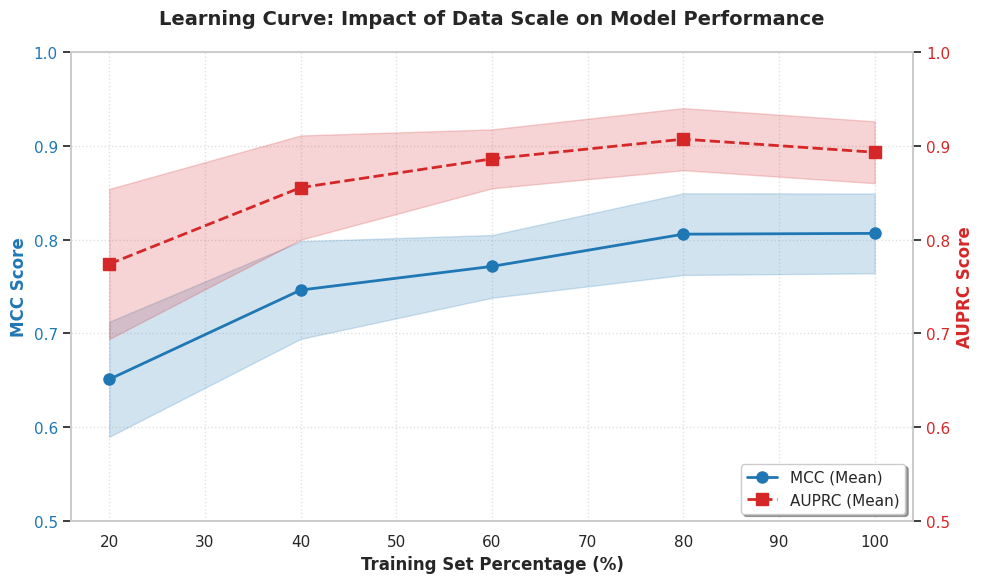

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================= 配置区域 =================
INPUT_FILE = "learning_curve_results.csv"
OUTPUT_IMG = "Figure_Learning_Curve.png"
DPI = 300  
# ===========================================

def plot_dual_axis_learning_curve():
    # 1. 读取数据
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"❌ 错误：找不到文件 {INPUT_FILE}，请确保它在当前目录下。")
        return

    # 2. 计算均值和标准差
    # 按照 Fraction 分组计算
    summary = df.groupby('Fraction').agg({
        'MCC': ['mean', 'std'],
        'AUPRC': ['mean', 'std'],
        'Sample_Size': 'mean'
    }).reset_index()

    # 提取绘图数据
    x = summary['Fraction'] * 100  
    x_labels = summary['Sample_Size']['mean'].astype(int) 
    
    mcc_mean = summary['MCC']['mean']
    mcc_std = summary['MCC']['std']
    
    auprc_mean = summary['AUPRC']['mean']
    auprc_std = summary['AUPRC']['std']

    # 3. 设置绘图风格
    sns.set(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- 绘制 MCC (左轴 - 蓝色) ---
    color_mcc = 'tab:blue'
    ax1.set_xlabel('Training Set Percentage (%)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MCC Score', color=color_mcc, fontsize=12, fontweight='bold')
    
    # 画线和点
    line1 = ax1.plot(x, mcc_mean, color=color_mcc, marker='o', linewidth=2, label='MCC (Mean)', markersize=8)
    # 画误差阴影 (Mean ± Std)
    ax1.fill_between(x, mcc_mean - mcc_std, mcc_mean + mcc_std, color=color_mcc, alpha=0.2)
    
    ax1.tick_params(axis='y', labelcolor=color_mcc)
    ax1.set_ylim(bottom=min(mcc_mean)*0.9, top=max(mcc_mean)*1.05) # 自动调整Y轴范围
    plt.ylim(0.5, 1)
    
    # --- 绘制 AUPRC (右轴 - 红色) ---
    ax2 = ax1.twinx()  # 创建共享 X 轴的第二个 Y 轴
    color_auprc = 'tab:red'
    ax2.set_ylabel('AUPRC Score', color=color_auprc, fontsize=12, fontweight='bold')
    
    line2 = ax2.plot(x, auprc_mean, color=color_auprc, marker='s', linestyle='--', linewidth=2, label='AUPRC (Mean)', markersize=8)
    ax2.fill_between(x, auprc_mean - auprc_std, auprc_mean + auprc_std, color=color_auprc, alpha=0.2)
    
    ax2.tick_params(axis='y', labelcolor=color_auprc)
    ax2.set_ylim(bottom=min(auprc_mean)*0.9, top=1.01) 
    # --- 4. 美化图表 ---
    plt.title('Learning Curve: Impact of Data Scale on Model Performance', fontsize=14, fontweight='bold', pad=20)
    
    # 合并图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', frameon=True, fancybox=True, shadow=True)

    # 网格线优化 (只显示主网格)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax2.grid(False) # 避免右轴网格线干扰

    plt.ylim(0.5, 1)

    # --- 5. 保存 ---
    plt.tight_layout()
    print(f"✅ 图表已生成并保存为: {OUTPUT_IMG}")
    plt.show()

if __name__ == "__main__":
    plot_dual_axis_learning_curve()

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
INPUT_DIR_TEMPLATE = "split_seed_{}" 
FIXED_ENCODING = "prot_t5"

EPOCHS = 70
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

class FinalSelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(FinalSelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),     
            nn.Linear(256, 64),  nn.ReLU(),                                      
            nn.Linear(64, 1)                                                     
        )
    def forward(self, x): return self.net(x)

def main():
    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_path = os.path.join(folder, "train_features.pkl")
        val_path = os.path.join(folder, "test_features.pkl")
        
        if not (os.path.exists(train_path) and os.path.exists(val_path)):
            continue
            
        print(f"🚀 Processing Seed {seed}: Training and extracting t-SNE coordinates...")
        
        # 1. 加载并合并数据集
        with open(train_path, 'rb') as f: tr_data = pickle.load(f)
        with open(val_path, 'rb') as f: va_data = pickle.load(f)
        combined_data = tr_data + va_data

        ids_all = [i['id'] for i in combined_data]
        X_all = np.stack([i[FIXED_ENCODING] for i in combined_data])
        y_all = np.array([i['label'] for i in combined_data])

        # 2. 标准化与转换
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all)
        X_t = torch.FloatTensor(X_scaled).to(DEVICE)
        y_t = torch.FloatTensor(y_all).unsqueeze(1).to(DEVICE)

        # 3. 训练模型
        model = FinalSelectionMLP(X_all.shape[1]).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        criterion = nn.BCEWithLogitsLoss()

        model.train()
        for epoch in range(1, EPOCHS + 1):
            optimizer.zero_grad()
            output = model(X_t)
            loss = criterion(output, y_t)
            loss.backward()
            optimizer.step()

        # 4. 提取层级特征
        model.eval()
        layers_data = {}
        with torch.no_grad():
            layers_data["Input_Layer"] = X_scaled
            layers_data["Hidden_1"] = model.net[0:3](X_t).cpu().numpy()
            layers_data["Hidden_2"] = model.net[0:7](X_t).cpu().numpy()
            layers_data["Hidden_3"] = model.net[0:10](X_t).cpu().numpy()
            
            # 同时提取预测概率，用于后续分析
            logits = model(X_t)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()

        # 5. 执行 t-SNE 并保存 CSV
        csv_export_list = []
        target_layers = ["Input_Layer", "Hidden_1", "Hidden_2", "Hidden_3"]
        
        for name in target_layers:
            print(f"  - Computing t-SNE for {name}...")
            tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
            X_emb = tsne.fit_transform(layers_data[name])
            
            temp_df = pd.DataFrame({
                'ID': ids_all,
                'Label': y_all,
                'Layer': name,
                'TSNE_1': X_emb[:, 0],
                'TSNE_2': X_emb[:, 1],
                'Pred_Prob': probs
            })
            csv_export_list.append(temp_df)

        # 合并所有层的数据并导出
        final_df = pd.concat(csv_export_list, axis=0)
        output_csv = os.path.join(folder, f"tsne_transformation_data_seed_{seed}.csv")
        final_df.to_csv(output_csv, index=False)

if __name__ == "__main__":
    main()

🚀 Processing Seed 42: Training and extracting t-SNE coordinates...
  - Computing t-SNE for Input_Layer...
  - Computing t-SNE for Hidden_1...
  - Computing t-SNE for Hidden_2...
  - Computing t-SNE for Hidden_3...
🚀 Processing Seed 2023: Training and extracting t-SNE coordinates...
  - Computing t-SNE for Input_Layer...
  - Computing t-SNE for Hidden_1...
  - Computing t-SNE for Hidden_2...
  - Computing t-SNE for Hidden_3...
🚀 Processing Seed 1234: Training and extracting t-SNE coordinates...
  - Computing t-SNE for Input_Layer...
  - Computing t-SNE for Hidden_1...
  - Computing t-SNE for Hidden_2...
  - Computing t-SNE for Hidden_3...
🚀 Processing Seed 567: Training and extracting t-SNE coordinates...
  - Computing t-SNE for Input_Layer...
  - Computing t-SNE for Hidden_1...
  - Computing t-SNE for Hidden_2...
  - Computing t-SNE for Hidden_3...
🚀 Processing Seed 100: Training and extracting t-SNE coordinates...
  - Computing t-SNE for Input_Layer...
  - Computing t-SNE for Hidden_1

图表已生成：'tsne_manifold_viz.png' 和 'tsne_manifold_viz.svg'


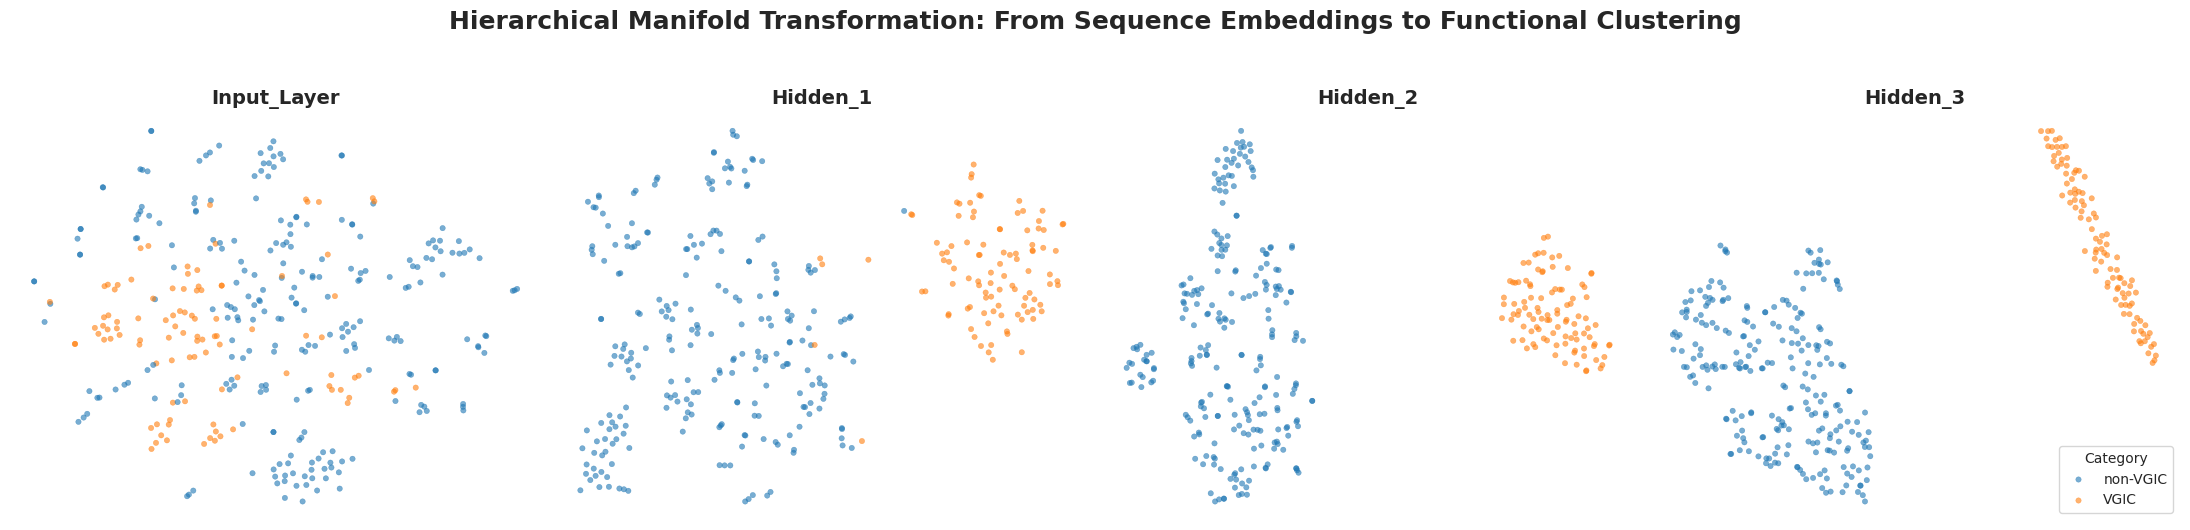

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取保存的 t-SNE 坐标数据
file_path = './split_seed_42/tsne_transformation_data_seed_42.csv'
df = pd.read_csv(file_path)

# 2. 设定展示顺序和颜色
target_layers = ["Input_Layer", "Hidden_1", "Hidden_2", "Hidden_3"]
# 确保只包含目标层级
df = df[df['Layer'].isin(target_layers)]

# 创建 1行 4列的画布
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
palette = {0: '#1f77b4', 1: '#ff7f0e'}  

# 3. 循环绘图
for i, name in enumerate(target_layers):
    layer_df = df[df['Layer'] == name]
    
    # 绘制散点图
    sns.scatterplot(
        data=layer_df,
        x='TSNE_1',
        y='TSNE_2',
        hue='Label',
        palette=palette,
        ax=axes[i],
        alpha=0.6,
        s=15,
        edgecolor=None,
        legend=(i == 3) 
    )
    
    axes[i].set_title(f"{name}", fontsize=14, fontweight='bold')
    axes[i].axis('off') 

# 4. 优化图例标签
if axes[3].get_legend():
    handles, labels = axes[3].get_legend_handles_labels()
    axes[3].legend(handles, ['non-VGIC', 'VGIC'], 
                   title="Category", loc='lower right', frameon=True)

# 5. 添加总标题并保存
plt.suptitle("Hierarchical Manifold Transformation: From Sequence Embeddings to Functional Clustering", 
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
print("图表已生成：'tsne_manifold_viz.png' 和 'tsne_manifold_viz.svg'")
plt.show()

In [92]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
INPUT_DIR_TEMPLATE = "split_seed_{}" 
FIXED_ENCODING = "prot_t5"

BATCH_SIZE = 32
EPOCHS = 100 
LEARNING_RATE = 0.0005
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# ===========================================

# --- 锁定模型结构 ---
class FinalSelectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(FinalSelectionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def main():
    all_loss_histories = []

    for seed in SEEDS:
        folder = INPUT_DIR_TEMPLATE.format(seed)
        train_path = os.path.join(folder, "train_features.pkl")
        val_path = os.path.join(folder, "test_features.pkl")
        
        if not (os.path.exists(train_path) and os.path.exists(val_path)):
            continue
            
        print(f"🚀 Training with Seed {seed}...")
        
        # 1. 加载并合并数据集 (训练集 + 验证集)
        with open(train_path, 'rb') as f: tr_data = pickle.load(f)
        with open(val_path, 'rb') as f: va_data = pickle.load(f)
        combined_data = tr_data + va_data

        X_all = np.stack([i[FIXED_ENCODING] for i in combined_data])
        y_all = np.array([i['label'] for i in combined_data])

        # 2. 标准化
        scaler = StandardScaler()
        X_all = scaler.fit_transform(X_all)

        # 3. 准备数据
        X_t = torch.FloatTensor(X_all).to(DEVICE)
        y_t = torch.FloatTensor(y_all).unsqueeze(1).to(DEVICE)

        # 4. 初始化
        model = FinalSelectionMLP(X_all.shape[1]).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        criterion = nn.BCEWithLogitsLoss()

        # 5. 训练循环并记录 Loss
        seed_loss_history = []
        for epoch in range(1, EPOCHS + 1):
            model.train()
            optimizer.zero_grad()
            output = model(X_t)
            loss = criterion(output, y_t)
            loss.backward()
            optimizer.step()
            
            current_loss = loss.item()
            seed_loss_history.append({'Seed': seed, 'Epoch': epoch, 'Loss': current_loss})
            
            if epoch % 10 == 0:
                print(f"   - Epoch {epoch:2d}/{EPOCHS}: Loss = {current_loss:.6f}")

        all_loss_histories.extend(seed_loss_history)
        
        # 保存单个种子的模型 (可选)
        torch.save(model.state_dict(), f"model_seed_{seed}.pth")

    # 保存所有 Loss 数据
    df_loss = pd.DataFrame(all_loss_histories)
    df_loss.to_csv("training_loss_history_all_seeds.csv", index=False)
    
    # 计算平均 Loss 趋势
    avg_loss_trend = df_loss.groupby('Epoch')['Loss'].agg(['mean', 'std'])
    avg_loss_trend.to_csv("average_loss_trend.csv")
    
    print("\n✅ 训练完成！Loss 数据已保存至: training_loss_history_all_seeds.csv")
    print("各 Epoch 平均 Loss 已汇总至: average_loss_trend.csv")

if __name__ == "__main__":
    main()

🚀 Training with Seed 42...
   - Epoch 10/100: Loss = 0.378069
   - Epoch 20/100: Loss = 0.199080
   - Epoch 30/100: Loss = 0.092565
   - Epoch 40/100: Loss = 0.037412
   - Epoch 50/100: Loss = 0.017993
   - Epoch 60/100: Loss = 0.008911
   - Epoch 70/100: Loss = 0.007152
   - Epoch 80/100: Loss = 0.003972
   - Epoch 90/100: Loss = 0.003058
   - Epoch 100/100: Loss = 0.002934
🚀 Training with Seed 2023...
   - Epoch 10/100: Loss = 0.380137
   - Epoch 20/100: Loss = 0.197090
   - Epoch 30/100: Loss = 0.092229
   - Epoch 40/100: Loss = 0.042615
   - Epoch 50/100: Loss = 0.021422
   - Epoch 60/100: Loss = 0.011602
   - Epoch 70/100: Loss = 0.007901
   - Epoch 80/100: Loss = 0.004401
   - Epoch 90/100: Loss = 0.004053
   - Epoch 100/100: Loss = 0.003135
🚀 Training with Seed 1234...
   - Epoch 10/100: Loss = 0.336024
   - Epoch 20/100: Loss = 0.159334
   - Epoch 30/100: Loss = 0.074736
   - Epoch 40/100: Loss = 0.031909
   - Epoch 50/100: Loss = 0.015671
   - Epoch 60/100: Loss = 0.007138
   

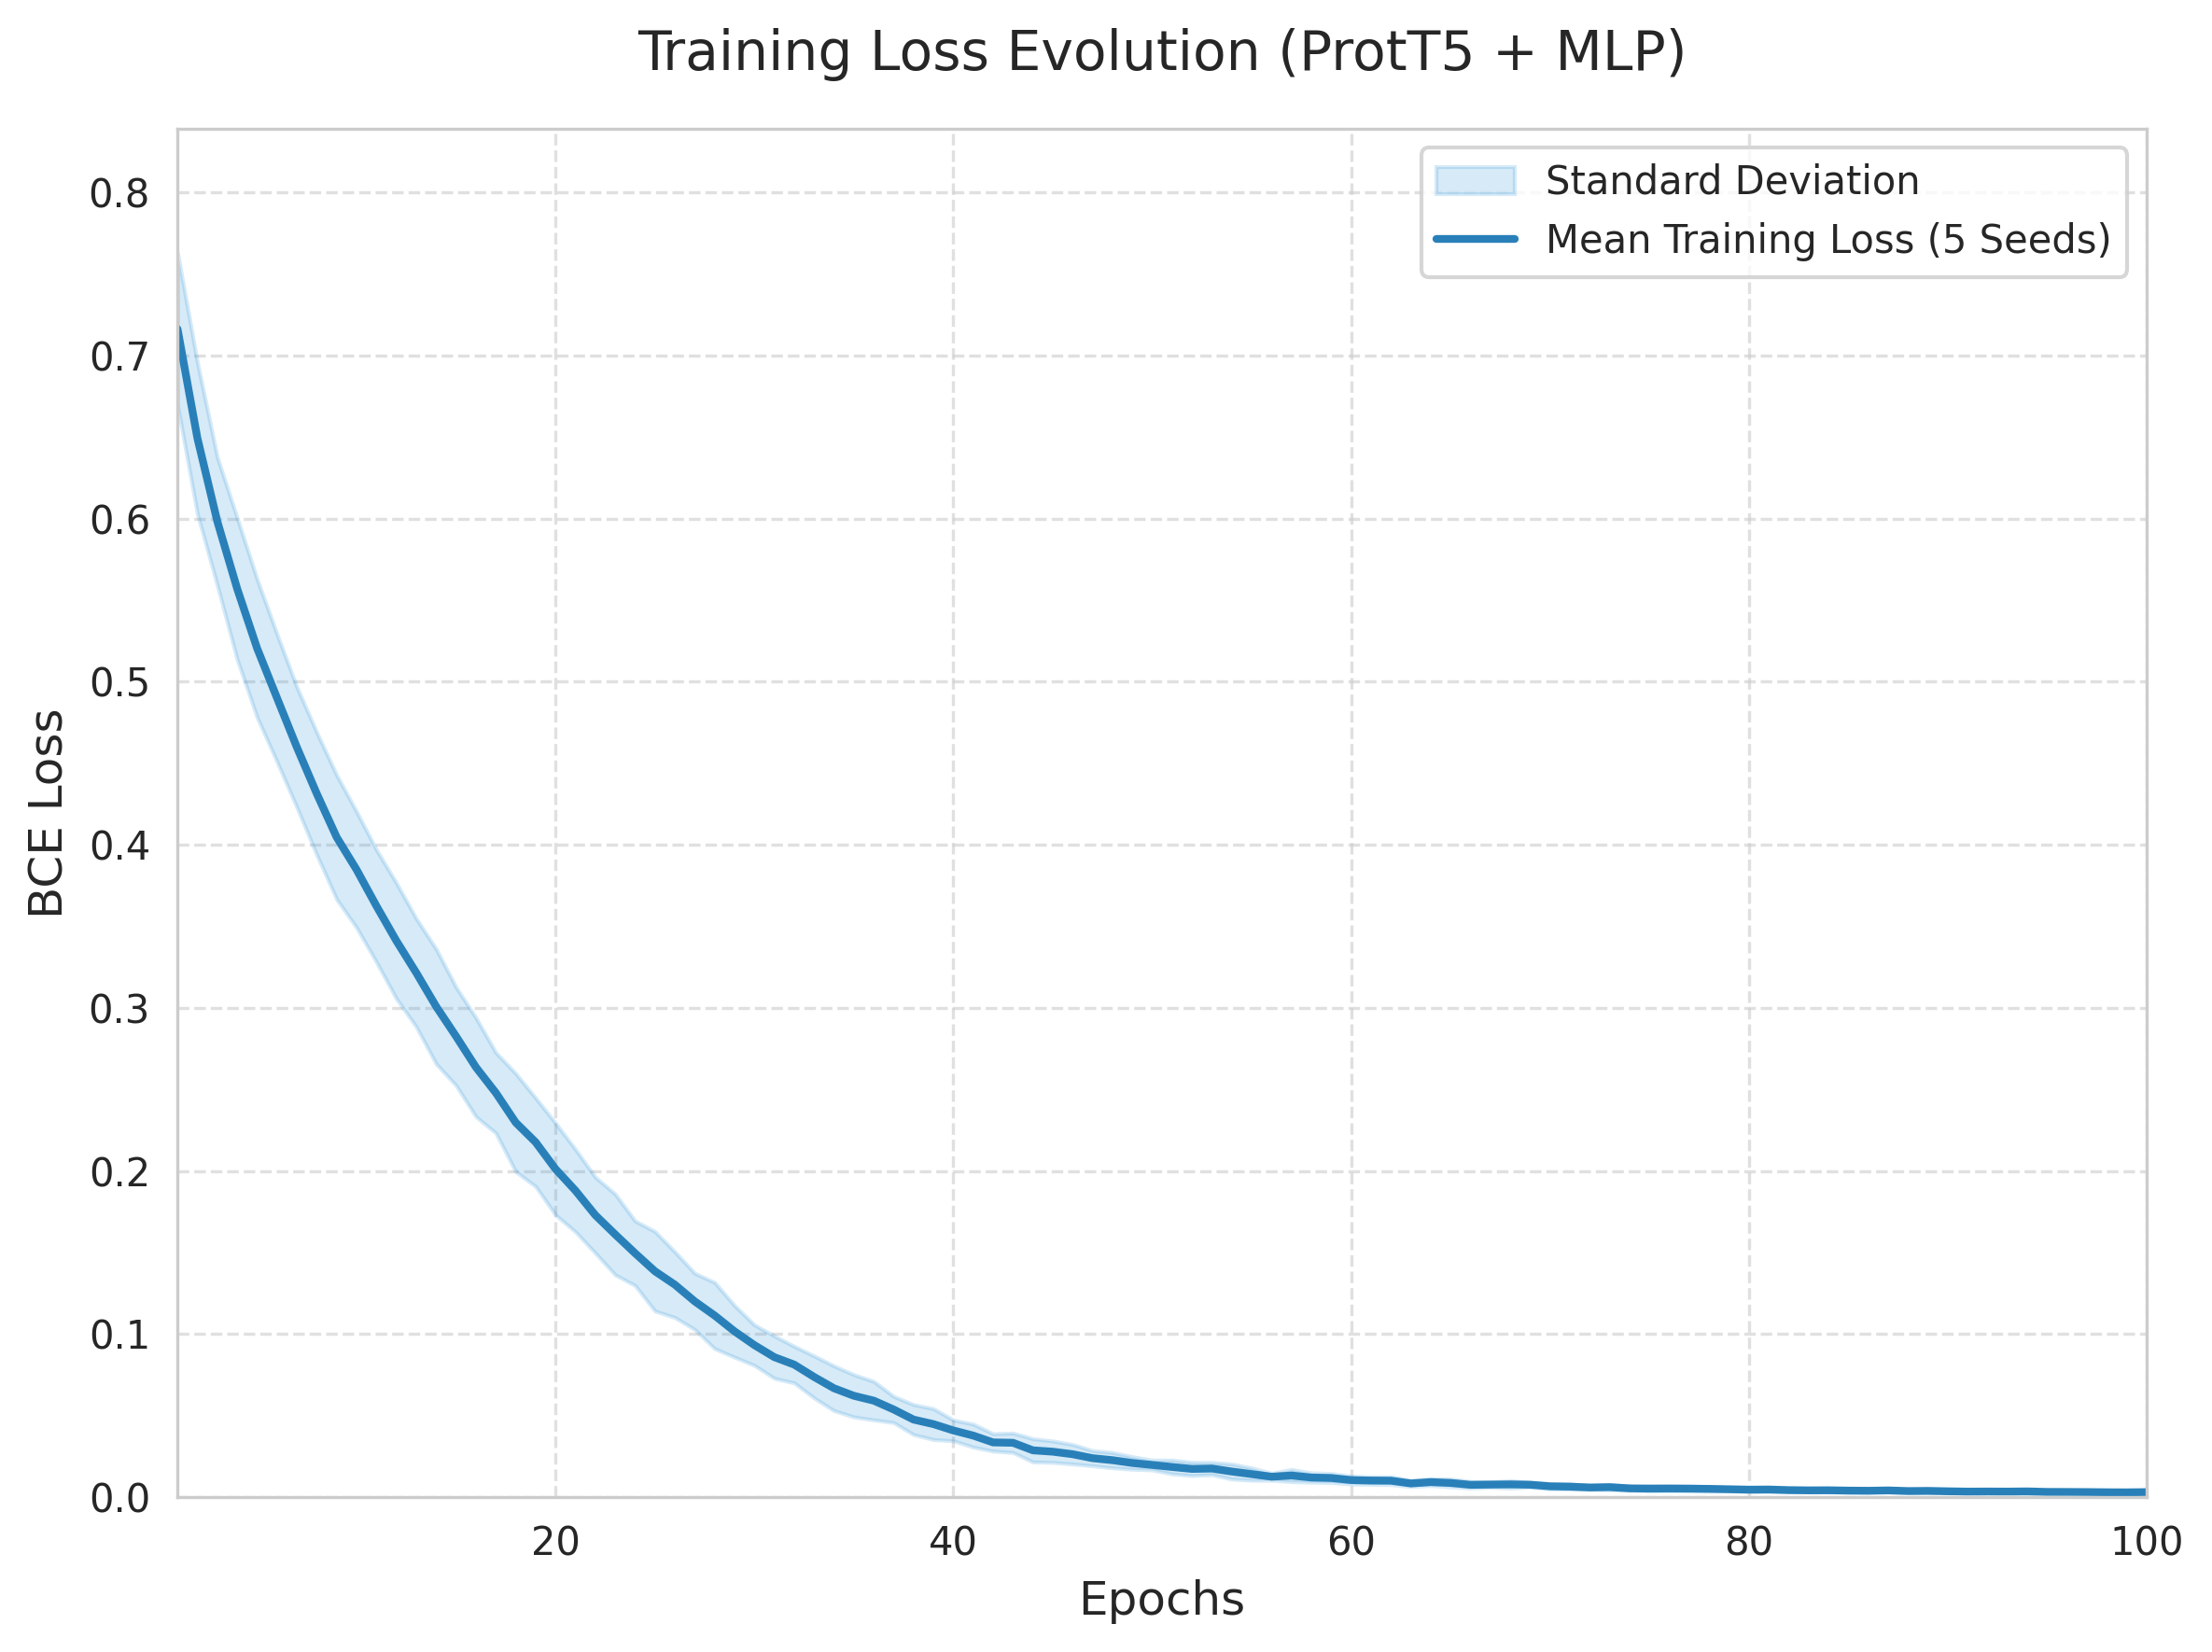

✅ 图像已保存至: loss_evolution.png


In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curve(csv_path, save_name="loss_evolution.png"):
    # 1. 读取汇总数据
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"错误: 找不到文件 {csv_path}，请先运行训练脚本生成数据。")
        return

    epochs = df['Epoch']
    mean_loss = df['mean']
    std_loss = df['std']

    # 2. 设置绘图风格 (学术论文常用风格)
    plt.figure(figsize=(8, 6), dpi=300)
    # plt.rcParams['font.sans-serif'] = ['Arial'] # 设置字体
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. 绘制阴影区域 (Mean ± Std)
    # alpha 控制阴影透明度
    plt.fill_between(epochs, 
                     mean_loss - std_loss, 
                     mean_loss + std_loss, 
                     color='#3498db', alpha=0.2, label='Standard Deviation')

    # 4. 绘制平均 Loss 主线
    plt.plot(epochs, mean_loss, color='#2980b9', linewidth=2, 
             label='Mean Training Loss (5 Seeds)')

    # 5. 添加标注和修饰
    plt.title('Training Loss Evolution (ProtT5 + MLP)', fontsize=14, pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('BCE Loss', fontsize=12)
    
    # 设置刻度范围，从 0 开始更直观
    plt.ylim(0, max(mean_loss + std_loss) * 1.1)
    plt.xlim(1, max(epochs))

    # 设置图例
    plt.legend(loc='upper right', frameon=True, fontsize=10)

    # 6. 保存与展示
    plt.tight_layout()
    # plt.savefig(save_name)
    plt.show()
    print(f"✅ 图像已保存至: {save_name}")

if __name__ == "__main__":
    # 使用你之前生成的汇总 CSV 文件
    plot_loss_curve("average_loss_trend.csv")